In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
zomato = pd.read_csv("Zomato-data.csv")
zomato.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Zomato-data.csv'

In [5]:
def handleRate(value):
    value=str(value).split('/')
    value=value[0];
    return float(value)

zomato['rate']=zomato['rate'].apply(handleRate)
zomato.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [6]:
zomato.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


In [7]:
zomato.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [16]:
zomato.rename(columns={'listed_in(type)':'rest_type'},inplace=True)

In [17]:
zomato.columns.tolist()

['name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'approx_cost(for two people)',
 'rest_type']

Text(0.5, 0, 'Restuarant Type')

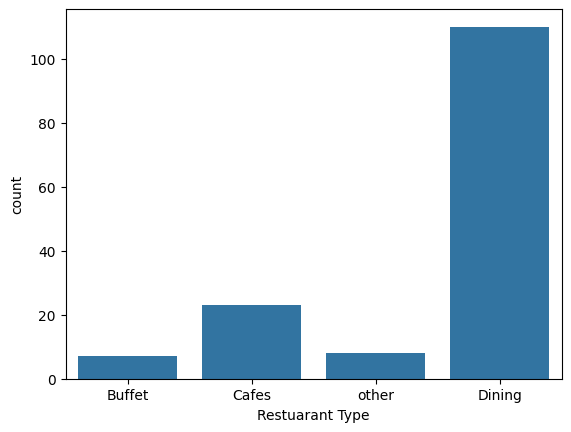

In [18]:
sns.countplot(x = zomato['rest_type'])
plt.xlabel("Restuarant Type")

Text(0, 0.5, 'Votes')

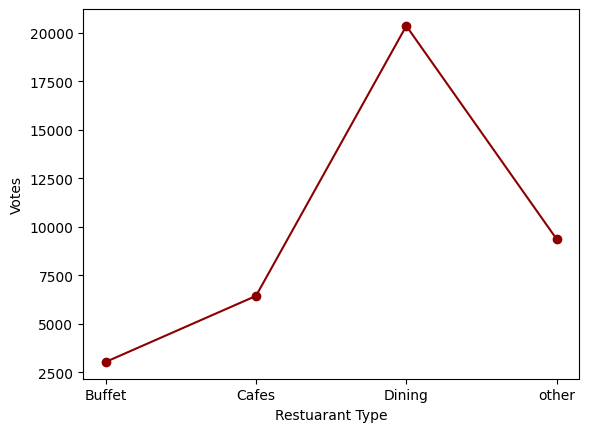

In [31]:
datagroup = zomato.groupby('rest_type')['votes'].sum()
res = pd.DataFrame({'votes':datagroup})
plt.plot(res,c = 'darkred',marker='o')
plt.xlabel("Restuarant Type")
plt.ylabel("Votes")

In [34]:
maxvote = zomato['votes'].max()
resmax = zomato.loc[zomato['votes'] == maxvote,'name']
resmax

38    Empire Restaurant
Name: name, dtype: object

Text(0.5, 0, 'Order Type Details')

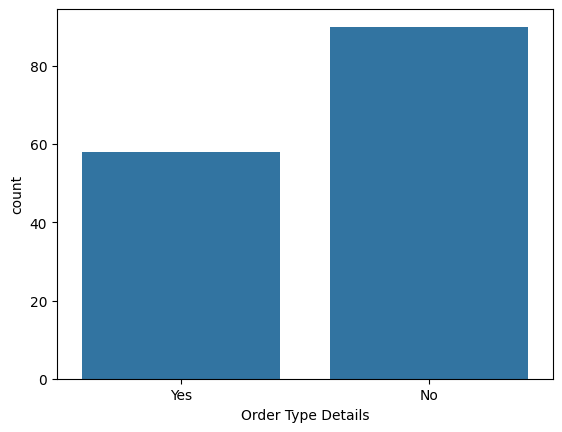

In [35]:
sns.countplot(x = zomato['online_order'])
plt.xlabel("Order Type Details")

Text(0.5, 0, 'Rating Frequency')

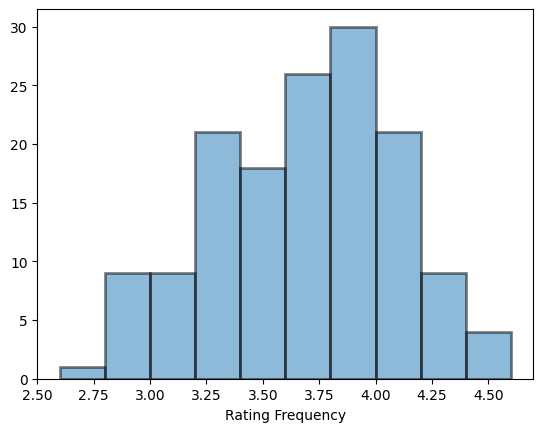

In [41]:
plt.hist(zomato['rate'],bins= 10,edgecolor='black',linestyle='-', alpha=0.5,linewidth =2)
plt.xlabel("Rating Frequency")

Text(0.5, 0, 'Couple cost')

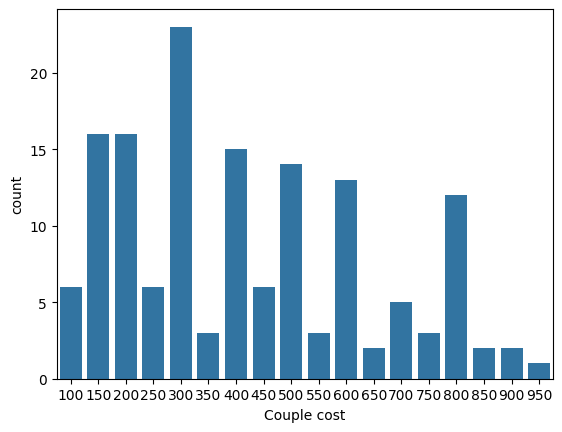

In [46]:
couplecost = zomato['approx_cost(for two people)']
sns.countplot(x = couplecost)
plt.xlabel("Couple cost")

Text(0.5, 0, 'Rating Comparision')

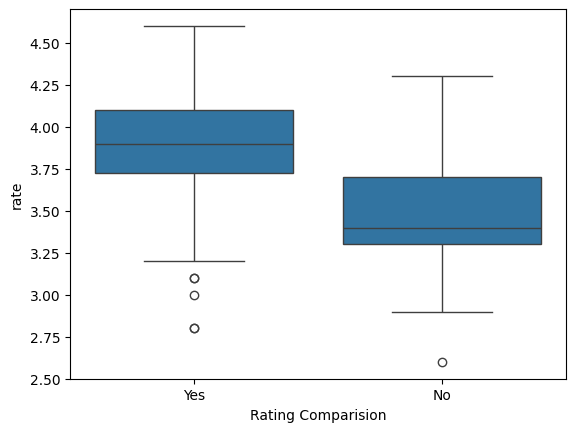

In [47]:
sns.boxplot(x = zomato['online_order'],y = zomato['rate'])
plt.xlabel("Rating Comparision")

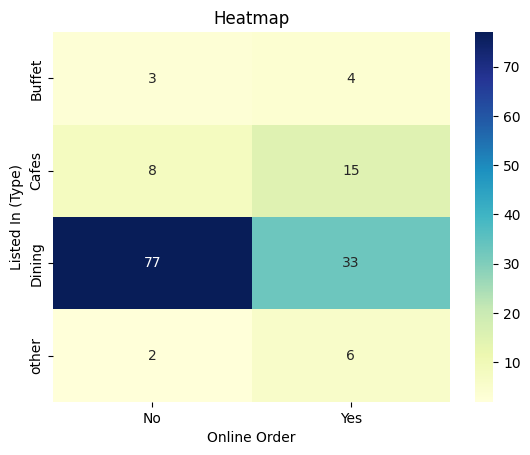

In [48]:
pivot_table = zomato.pivot_table(index='rest_type', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()